# 05: Interactive STRING Interaction Networks Colored by pLLPS Score

Build interactive STRING protein-protein interaction networks for functional groups (e.g., Ion Channels) where:
- **Nodes** = Proteins in the functional group
- **Node color** = pLLPS score (blue=low, white=medium, red=high)
- **Edge thickness** = STRING interaction confidence score
- **Interactive exploration** = Hover for details, drag to explore

This notebook creates both static (PNG) and interactive (HTML) visualizations optimized for publication and exploration.

**Workflow:**
1. Load pLLPS scores and functional group classifications
2. Select target functional group (e.g., Ion Channels)
3. Query STRING database for protein-protein interactions
4. Build NetworkX graph with node and edge attributes
5. Visualize with pLLPS coloring and STRING score weighting
6. Export as interactive HTML and publication-quality PNG

In [1]:
# Install required libraries if not already installed
import subprocess
import sys

packages = ['networkx', 'pyvis', 'plotly', 'kaleido']
for package in packages:
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("✅ All packages ready")

✅ All packages ready


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import json
import importlib
from pathlib import Path
from matplotlib.colors import Normalize, LinearSegmentedColormap
import llps_functions as lf
from pyvis.network import Network
import warnings
warnings.filterwarnings('ignore')

# Reload module
importlib.reload(lf)

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 14)
plt.rcParams['font.size'] = 10

# Output directories
OUTPUT_DIR = Path('results/functional_group_networks')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Color map for pLLPS scores (blue=low, white=medium, red=high)
PLLPS_CMAP = LinearSegmentedColormap.from_list('pllps', ['#0571b0', '#f7f7f7', '#ca0020'])

print("✅ Libraries imported and configured successfully")
print(f"Output directory: {OUTPUT_DIR}")

✅ Libraries imported and configured successfully
Output directory: results/functional_group_networks


## 1. Load pLLPS Scores and Functional Groups

In [3]:
# Load pLLPS data and classify by functional group
print("📚 Loading pLLPS data...")
df_full = lf.load_analysis_result('full_dataset', format='csv')

print(f"\n📊 Dataset Loaded:")
print(f"   Total proteins: {len(df_full)}")
print(f"   pLLPS scores available: {df_full['p(LLPS)'].notna().sum()}")

# Add functional categories using the new YAML-based parser
print("\n🔍 Classifying proteins by functional groups (using YAML-based parser)...")
df_full = lf.add_functional_categories(df_full)

# Create a 'Functional Group' column for compatibility with existing code
# If protein has multiple categories, use the first one
df_full['Functional Group'] = df_full['Functional_Categories'].apply(
    lambda cats: cats[0] if isinstance(cats, list) and len(cats) > 0 else 'Other'
)

# Filter to proteins that have at least one functional category
df_groups = df_full[df_full['Functional_Categories'].apply(len) > 0].copy()

# Create a version with one row per category (exploded)
df_exploded = df_groups.explode('Functional_Categories').reset_index(drop=True)
df_exploded['Functional Group'] = df_exploded['Functional_Categories']
df_exploded = df_exploded.drop(columns=['Functional_Categories'])

print(f"\n✅ Classification Complete:")
print(f"   Proteins with functional annotations: {len(df_groups)}")
print(f"   Unique functional groups: {df_groups['Functional Group'].nunique()}")
print(f"\n📋 Functional Group Distribution:")
group_counts = df_exploded['Functional Group'].value_counts()
for group, count in group_counts.head(15).items():
    pct = 100 * count / len(df_exploded)
    print(f"   {group}: {count} proteins ({pct:.1f}%)")

# Create pLLPS lookup dictionary
pllps_dict = dict(zip(df_full['Entry'], df_full['p(LLPS)']))
print(f"\n✅ pLLPS lookup dictionary created with {len(pllps_dict)} entries")

📚 Loading pLLPS data...
✅ Loaded CSV from: results/full_dataset.csv (20366 rows)

📊 Dataset Loaded:
   Total proteins: 20366
   pLLPS scores available: 20366

🔍 Classifying proteins by functional groups (using YAML-based parser)...
✅ Added functional categories to 20366 proteins
   Categories found: ['Adhesion', 'Chaperone', 'GPCR', 'GTPase', 'Guanine Nucleotide Exchange Factor', 'Hydrolase', 'Ion Channel', 'Kinase', 'Ligase', 'Nuclear Receptor', 'Oxidoreductase', 'Phosphatase', 'Protease', 'Receptor', 'Receptor Tyrosine Kinase', 'Structural', 'Synthetase', 'Transcription Factor', 'Transferase', 'Transporter']
   Total category assignments: 15373

✅ Classification Complete:
   Proteins with functional annotations: 10528
   Unique functional groups: 19

📋 Functional Group Distribution:
   Receptor: 3218 proteins (20.9%)
   Structural: 1770 proteins (11.5%)
   Kinase: 1500 proteins (9.8%)
   Transcription Factor: 1109 proteins (7.2%)
   Hydrolase: 986 proteins (6.4%)
   Ligase: 872 prote

In [4]:
# Configuration
TARGET_GROUP = 'Structural'  # Change this to analyze different groups

# Get available groups from the data
available_groups = sorted(df_exploded['Functional Group'].unique())

print(f"Available functional groups ({len(available_groups)}):")
for i, group in enumerate(available_groups, 1):
    count = (df_exploded['Functional Group'] == group).sum()
    print(f"   {i:2d}. {group} ({count} proteins)")

print(f"\n🎯 Selected group: {TARGET_GROUP}")
if TARGET_GROUP not in available_groups:
    print(f"⚠️  Warning: '{TARGET_GROUP}' not found in available groups!")
    print(f"   Please select from the list above")

Available functional groups (20):
    1. Adhesion (841 proteins)
    2. Chaperone (272 proteins)
    3. GPCR (243 proteins)
    4. GTPase (573 proteins)
    5. Guanine Nucleotide Exchange Factor (188 proteins)
    6. Hydrolase (986 proteins)
    7. Ion Channel (475 proteins)
    8. Kinase (1500 proteins)
    9. Ligase (872 proteins)
   10. Nuclear Receptor (195 proteins)
   11. Oxidoreductase (673 proteins)
   12. Phosphatase (427 proteins)
   13. Protease (557 proteins)
   14. Receptor (3218 proteins)
   15. Receptor Tyrosine Kinase (111 proteins)
   16. Structural (1770 proteins)
   17. Synthetase (321 proteins)
   18. Transcription Factor (1109 proteins)
   19. Transferase (528 proteins)
   20. Transporter (514 proteins)

🎯 Selected group: Structural


In [5]:
# Export high pLLPS proteins for each functional category (separate CSV per group)
print(f"\n{'='*70}")
print(f"EXPORTING HIGH pLLPS PROTEINS BY FUNCTIONAL CATEGORY")
print(f"{'='*70}")

# Create subdirectory for per-function CSVs
per_function_dir = OUTPUT_DIR / 'pllps_by_function'
per_function_dir.mkdir(exist_ok=True)

print(f"\n📂 Creating per-function CSV files in: {per_function_dir}")

all_exported_files = []

for category in sorted(df_exploded['Functional Group'].unique()):
    # Get all proteins in this category
    category_proteins = df_exploded[df_exploded['Functional Group'] == category].copy()
    
    # Sort by pLLPS score (descending) to show highest first
    category_proteins = category_proteins.sort_values('p(LLPS)', ascending=False)
    
    # Create output DataFrame with all proteins (especially useful for ties at pLLPS=1.0)
    output_data = []
    for idx, (_, row) in enumerate(category_proteins.iterrows(), 1):
        output_data.append({
            'Rank': idx,
            'UniProt_ID': row['Entry'],
            'STRING_ID': row['Entry name'],
            'Protein_Names': row['Protein names'],
            'pLLPS_Score': row['p(LLPS)']
        })
    
    # Export to CSV
    output_df = pd.DataFrame(output_data)
    filename = f"{category.lower().replace(' ', '_').replace('/', '_')}_pllps.csv"
    output_file = per_function_dir / filename
    output_df.to_csv(output_file, index=False)
    all_exported_files.append(output_file)
    
    # Print summary for this category
    high_pllps_count = (category_proteins['p(LLPS)'] >= 0.7).sum()
    perfect_pllps_count = (category_proteins['p(LLPS)'] == 1.0).sum()
    print(f"\n{category}:")
    print(f"   Total proteins: {len(category_proteins)}")
    print(f"   pLLPS = 1.0: {perfect_pllps_count}")
    print(f"   pLLPS ≥ 0.7: {high_pllps_count}")
    print(f"   File: {filename}")

print(f"\n{'='*70}")
print(f"✅ Per-function pLLPS files exported")
print(f"   Directory: {per_function_dir}")
print(f"   Files created: {len(all_exported_files)}")
print(f"{'='*70}\n")


EXPORTING HIGH pLLPS PROTEINS BY FUNCTIONAL CATEGORY

📂 Creating per-function CSV files in: results/functional_group_networks/pllps_by_function

Adhesion:
   Total proteins: 841
   pLLPS = 1.0: 67
   pLLPS ≥ 0.7: 264
   File: adhesion_pllps.csv

Chaperone:
   Total proteins: 272
   pLLPS = 1.0: 13
   pLLPS ≥ 0.7: 64
   File: chaperone_pllps.csv

GPCR:
   Total proteins: 243
   pLLPS = 1.0: 11
   pLLPS ≥ 0.7: 37
   File: gpcr_pllps.csv

GTPase:
   Total proteins: 573
   pLLPS = 1.0: 39
   pLLPS ≥ 0.7: 183
   File: gtpase_pllps.csv

Guanine Nucleotide Exchange Factor:
   Total proteins: 188
   pLLPS = 1.0: 16
   pLLPS ≥ 0.7: 81
   File: guanine_nucleotide_exchange_factor_pllps.csv

Hydrolase:
   Total proteins: 986
   pLLPS = 1.0: 50
   pLLPS ≥ 0.7: 286
   File: hydrolase_pllps.csv

Ion Channel:
   Total proteins: 475
   pLLPS = 1.0: 17
   pLLPS ≥ 0.7: 105
   File: ion_channel_pllps.csv

Kinase:
   Total proteins: 1500
   pLLPS = 1.0: 129
   pLLPS ≥ 0.7: 500
   File: kinase_pllps.csv

L

## 2. Select Functional Group and Load STRING Interactions

In [ ]:
# Get proteins in the target group (TARGET_GROUP set in previous cell)
group_proteins = df_exploded[df_exploded['Functional Group'] == TARGET_GROUP].copy()
protein_ids = group_proteins['Entry'].unique().tolist()  # Use unique in case of duplicates

print(f"\n{'='*70}")
print(f"TARGET FUNCTIONAL GROUP: {TARGET_GROUP}")
print(f"{'='*70}")
print(f"\n📌 Group Statistics:")
print(f"   Total proteins: {len(protein_ids)}")
print(f"   pLLPS range: [{group_proteins['p(LLPS)'].min():.3f}, {group_proteins['p(LLPS)'].max():.3f}]")
print(f"   Mean pLLPS: {group_proteins['p(LLPS)'].mean():.3f}")
print(f"   High pLLPS (>0.7): {(group_proteins['p(LLPS)'] > 0.7).sum()}")
print(f"   Medium pLLPS (0.4-0.7): {((group_proteins['p(LLPS)'] >= 0.4) & (group_proteins['p(LLPS)'] <= 0.7)).sum()}")
print(f"   Low pLLPS (<0.4): {(group_proteins['p(LLPS)'] < 0.4).sum()}")

# Load STRING interactions for this group if available
string_file = Path('results/string_networks_by_group') / f"{TARGET_GROUP.lower().replace(' ', '_')}_interactions.csv"

if string_file.exists():
    print(f"\n📁 Loading pre-computed STRING interactions: {string_file}")
    interactions_df = pd.read_csv(string_file)
    print(f"   Found {len(interactions_df)} interactions")
else:
    print(f"\n⚠️  No pre-computed interactions file found at {string_file}")
    print(f"   Nodes will be shown without interaction edges.")
    interactions_df = None


TARGET FUNCTIONAL GROUP: Structural

📌 Group Statistics:
   Total proteins: 1443
   pLLPS range: [0.060, 1.000]
   Mean pLLPS: 0.557
   High pLLPS (>0.7): 561
   Medium pLLPS (0.4-0.7): 262
   Low pLLPS (<0.4): 620

📁 Loading pre-computed STRING interactions: results/string_networks_by_group/structural_interactions.csv
   Found 311 interactions


## 3. Build NetworkX Graph with pLLPS Node Attributes and STRING Edge Weights

In [45]:
# Build network graph
print(f"\n{'='*70}")
print(f"BUILDING NETWORK GRAPH")
print(f"{'='*70}")

# Create graph
G = nx.Graph()

if interactions_df is not None and len(interactions_df) > 0:
    # Use pre-computed interactions
    print(f"\n📊 Processing {len(interactions_df)} interactions...")
    
    # Add edges and nodes from interactions
    for idx, row in interactions_df.iterrows():
        protein_id = row['protein']
        partner_id = row['partner']
        score = row.get('combined_score', row.get('score', 0))
        
        # Normalize STRING score (typically 0-1000) to 0-1
        if score > 100:
            score_normalized = score / 1000.0
        else:
            score_normalized = score
        
        # Get pLLPS scores
        pllps_1 = pllps_dict.get(protein_id, np.nan)
        pllps_2 = pllps_dict.get(partner_id, np.nan)
        
        # Add edge with STRING score as weight
        G.add_edge(protein_id, partner_id, weight=score_normalized, string_score=score, string_score_norm=score_normalized)
        
        # Set node attributes - use gene names from interaction file
        if protein_id not in G.nodes:
            G.nodes[protein_id]['pllps'] = pllps_1
            G.nodes[protein_id]['protein_name'] = row.get('protein_name', protein_id)  # Gene name from STRING
            G.nodes[protein_id]['uniprot_id'] = protein_id
        
        if partner_id not in G.nodes:
            G.nodes[partner_id]['pllps'] = pllps_2
            G.nodes[partner_id]['protein_name'] = row.get('partner_name', partner_id)  # Gene name from STRING
            G.nodes[partner_id]['uniprot_id'] = partner_id

    # Add any group proteins that did not appear in the interaction list (isolated nodes)
    added_isolated = 0
    for prot_id in protein_ids:
        if prot_id not in G.nodes:
            pllps_val = pllps_dict.get(prot_id, np.nan)
            name_series = group_proteins.loc[group_proteins['Entry'] == prot_id, 'Entry name']
            prot_name = name_series.values[0] if len(name_series) > 0 else prot_id
            G.add_node(prot_id, pllps=pllps_val, protein_name=prot_name, uniprot_id=prot_id)
            added_isolated += 1
    if added_isolated > 0:
        print(f"   Added {added_isolated} isolated nodes (no STRING edges at cutoff)")
else:
    print(f"\n⚠️  No interactions file found. Building network from proteins in group...")
    # Add all proteins from the group as nodes
    for prot_id in protein_ids:
        pllps = pllps_dict.get(prot_id, np.nan)
        prot_name = group_proteins[group_proteins['Entry'] == prot_id]['Entry name'].values
        prot_name = prot_name[0] if len(prot_name) > 0 else prot_id
        G.add_node(prot_id, pllps=pllps, protein_name=prot_name, uniprot_id=prot_id)
    print(f"   Added {G.number_of_nodes()} nodes (no edges without interaction data)")

# Ensure all nodes have pLLPS values from the lookup table
for node in G.nodes():
    if 'pllps' not in G.nodes[node] or pd.isna(G.nodes[node].get('pllps')):
        G.nodes[node]['pllps'] = pllps_dict.get(node, np.nan)

print(f"\n🌐 Network Statistics:")
print(f"   Nodes: {G.number_of_nodes()}")
print(f"   Edges: {G.number_of_edges()}")
print(f"   Density: {nx.density(G):.4f}")
print(f"   Connected components: {nx.number_connected_components(G)}")

if G.number_of_nodes() > 0:
    degrees = [G.degree(n) for n in G.nodes()]
    print(f"   Average degree: {np.mean(degrees):.2f}")
    print(f"   Max degree: {max(degrees)}")
    
    # pLLPS statistics
    pllps_values = [G.nodes[n].get('pllps', np.nan) for n in G.nodes()]
    pllps_values = [p for p in pllps_values if pd.notna(p)]
    if pllps_values:
        print(f"   pLLPS values in network: {len(pllps_values)}/{G.number_of_nodes()}")
        print(f"   Mean pLLPS: {np.mean(pllps_values):.3f}")
        print(f"   pLLPS range: [{min(pllps_values):.3f}, {max(pllps_values):.3f}]")
        print(f"   High pLLPS (>0.7): {sum(p > 0.7 for p in pllps_values)}")
    
    # Edge weight statistics
    edge_scores = [G[u][v].get('string_score_norm', 0) for u, v in G.edges()]
    if edge_scores:
        print(f"   STRING score range: [{min(edge_scores):.3f}, {max(edge_scores):.3f}]")
        print(f"   Mean STRING score: {np.mean(edge_scores):.3f}")

print(f"\n✅ Network graph created successfully")


BUILDING NETWORK GRAPH

📊 Processing 311 interactions...
   Added 1101 isolated nodes (no STRING edges at cutoff)

🌐 Network Statistics:
   Nodes: 1443
   Edges: 311
   Density: 0.0003
   Connected components: 1208
   Average degree: 0.43
   Max degree: 8
   pLLPS values in network: 1443/1443
   Mean pLLPS: 0.557
   pLLPS range: [0.060, 1.000]
   High pLLPS (>0.7): 561
   STRING score range: [0.701, 0.999]
   Mean STRING score: 0.911

✅ Network graph created successfully


## 4. Prepare Node Colors and Edge Weights for Visualization

In [46]:
# Prepare visualization attributes
print(f"\n{'='*70}")
print(f"PREPARING VISUALIZATION ATTRIBUTES")
print(f"{'='*70}")

# Extract node colors (pLLPS scores) and sizes (degree)
node_colors = []
node_sizes = []
node_pllps_values = []

for node in G.nodes():
    pllps = G.nodes[node].get('pllps', np.nan)
    degree = G.degree(node)
    
    node_colors.append(pllps if pd.notna(pllps) else 0.5)
    node_pllps_values.append(pllps if pd.notna(pllps) else 0.5)
    
    # Node size based on degree: bigger nodes have more connections
    size = 500 + (degree * 150)  # Scale by connectivity
    node_sizes.append(size)

# Extract edge widths (STRING scores)
edge_widths = []
for u, v in G.edges():
    score_norm = G[u][v].get('string_score_norm', G[u][v].get('weight', 0))
    width = 0.5 + (score_norm * 4)  # Scale width from 0.5 to 4.5
    edge_widths.append(width)

# Handle missing or NaN values in node colors
node_colors_valid = np.array([c if pd.notna(c) and not np.isnan(c) else 0.5 for c in node_colors])

print(f"\n📊 Visualization Attributes:")
print(f"   Node color range: [{node_colors_valid.min():.3f}, {node_colors_valid.max():.3f}]")
if node_sizes:
    print(f"   Node size range: [{min(node_sizes):.0f}, {max(node_sizes):.0f}]")
if edge_widths:
    print(f"   Edge width range: [{min(edge_widths):.2f}, {max(edge_widths):.2f}]")
print(f"   Proteins with pLLPS values: {sum(pd.notna(p) for p in node_pllps_values)}/{len(node_pllps_values)}")

print(f"\n✅ Visualization attributes prepared")


PREPARING VISUALIZATION ATTRIBUTES

📊 Visualization Attributes:
   Node color range: [0.060, 1.000]
   Node size range: [500, 1700]
   Edge width range: [3.30, 4.50]
   Proteins with pLLPS values: 1443/1443

✅ Visualization attributes prepared


## 5. Create Publication-Quality Static Visualization (PNG)


CREATING PUBLICATION-QUALITY STATIC VISUALIZATION

📐 Computing Kamada-Kawai layout (respects edge weights)...
   ✓ Successfully computed layout for 1443 nodes
   Drawing 311 edges...
   Drawing 1443 nodes...
   Adding labels for all 1443 nodes...

💾 Saving high-resolution PNG: results/functional_group_networks/structural_network.png
   Note: This is a reference visualization. For publication-quality layouts,
         use Cytoscape with the exported .cyjs file.
   ✅ Saved: results/functional_group_networks/structural_network.png


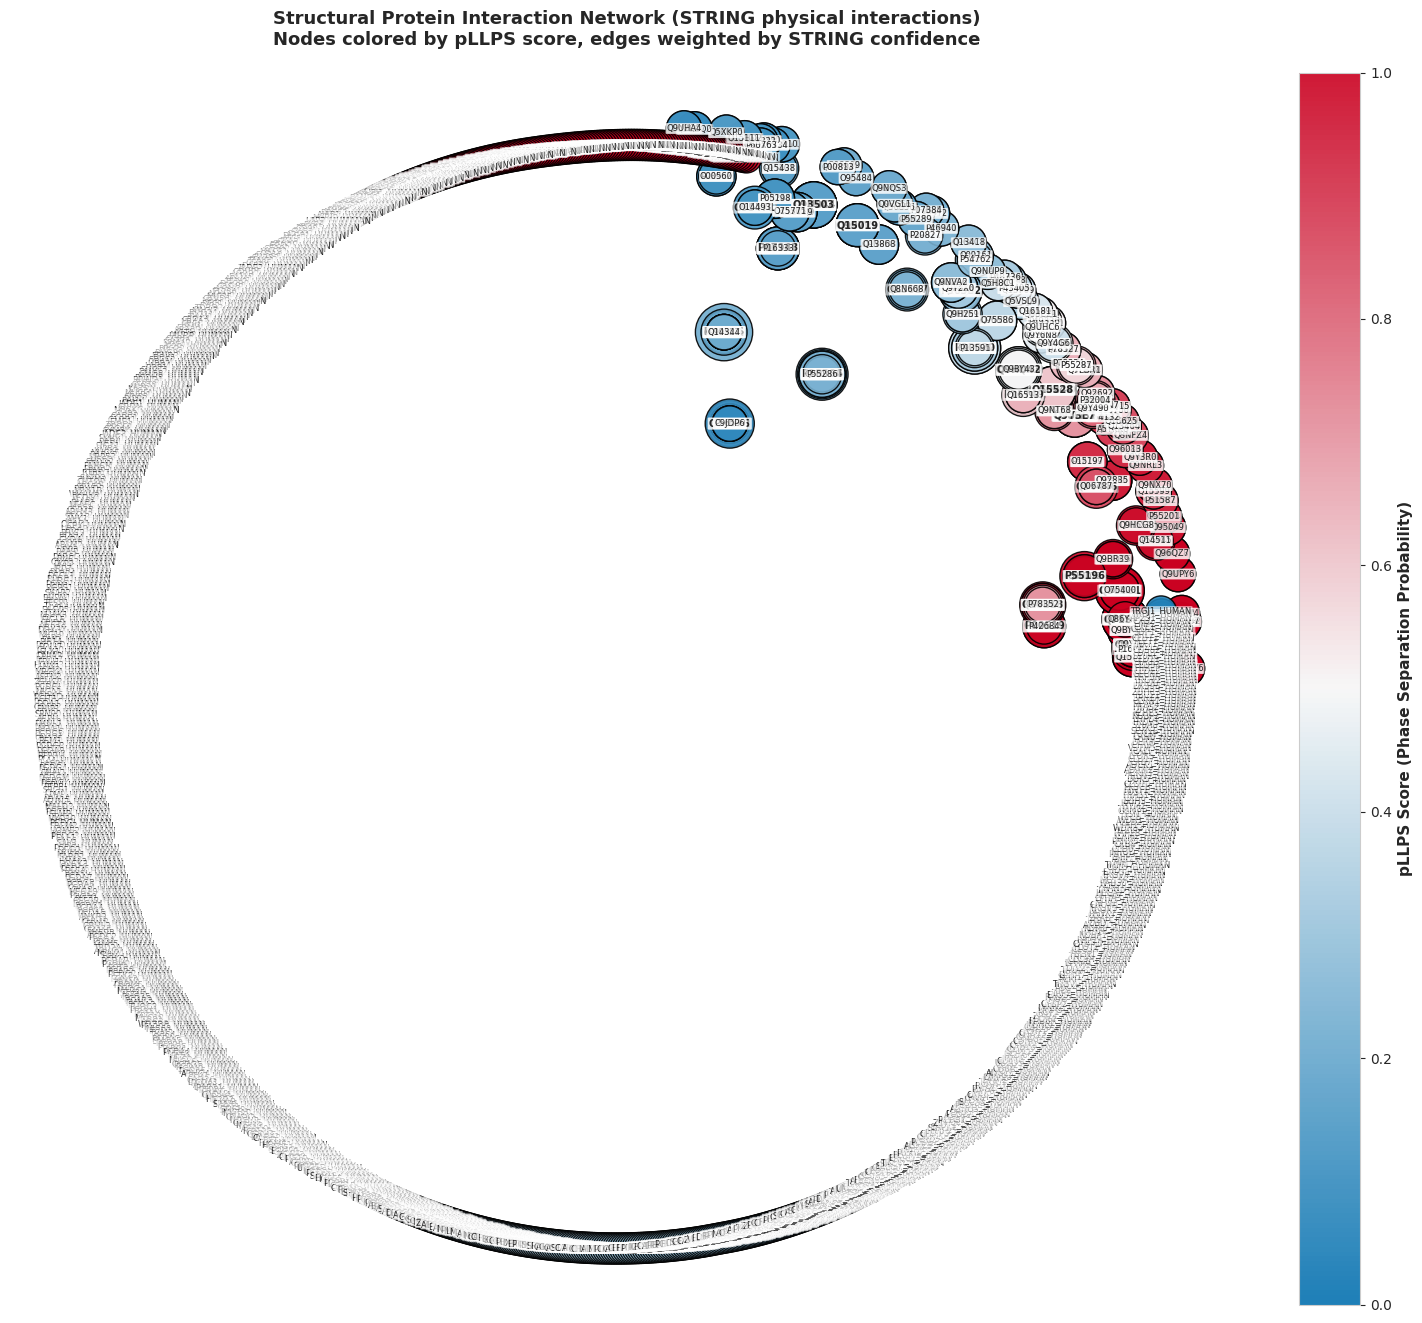

In [47]:
# Create publication-quality static visualization
print(f"\n{'='*70}")
print(f"CREATING PUBLICATION-QUALITY STATIC VISUALIZATION")
print(f"{'='*70}")

if G.number_of_nodes() > 0:
    # Use Kamada-Kawai layout (respects edge weights, like STRING does)
    print(f"\n📐 Computing Kamada-Kawai layout (respects edge weights)...")
    
    try:
        pos = nx.kamada_kawai_layout(G, weight='weight')
        print(f"   ✓ Successfully computed layout for {G.number_of_nodes()} nodes")
    except Exception as e:
        print(f"   ⚠️  Kamada-Kawai failed ({str(e)[:50]}), using spring layout...")
        pos = nx.spring_layout(G, k=0.5, iterations=200, seed=42, weight='weight')

    # Create figure
    fig, ax = plt.subplots(figsize=(18, 16))
    
    # Draw edges with varying thickness based on STRING score
    print(f"   Drawing {G.number_of_edges()} edges...")
    for (u, v), width in zip(G.edges(), edge_widths):
        score_norm = G[u][v].get('string_score_norm', 0)
        alpha = 0.25 + (score_norm * 0.5)  # Opacity based on score
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color='gray', alpha=alpha, linewidth=width, zorder=1)
    
    # Draw nodes with pLLPS coloring
    print(f"   Drawing {G.number_of_nodes()} nodes...")
    scatter = ax.scatter([pos[node][0] for node in G.nodes()],
                         [pos[node][1] for node in G.nodes()],
                         c=node_colors_valid,
                         s=node_sizes,
                         cmap=PLLPS_CMAP,
                         vmin=0, vmax=1,
                         edgecolors='black',
                         linewidths=1.0,
                         zorder=2,
                         alpha=0.9)
    
    # Add labels for all nodes using gene/protein names
    print(f"   Adding labels for all {G.number_of_nodes()} nodes...")
    for node in G.nodes():
        prot_name = G.nodes[node].get('protein_name', node)
        # Smaller font for non-hub nodes
        fontsize = 6 if G.degree(node) < 3 else 7
        fontweight = 'normal' if G.degree(node) < 3 else 'bold'
        ax.text(pos[node][0], pos[node][1], prot_name, fontsize=fontsize, fontweight=fontweight, ha='center', va='center',
               bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.6, edgecolor='none'))
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, label='pLLPS Score', fraction=0.046, pad=0.04)
    cbar.set_label('pLLPS Score (Phase Separation Probability)', fontsize=11, fontweight='bold')
    
    # Title and formatting
    title = f"{TARGET_GROUP} Protein Interaction Network (STRING physical interactions)\nNodes colored by pLLPS score, edges weighted by STRING confidence"
    ax.set_title(title, fontsize=13, fontweight='bold', pad=20)
    ax.axis('off')
    ax.set_aspect('equal')
    
    # Save figure
    output_file = OUTPUT_DIR / f"{TARGET_GROUP.lower().replace(' ', '_')}_network.png"
    print(f"\n💾 Saving high-resolution PNG: {output_file}")
    print(f"   Note: This is a reference visualization. For publication-quality layouts,")
    print(f"         use Cytoscape with the exported .cyjs file.")
    plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"   ✅ Saved: {output_file}")
    plt.show()
    plt.close()
else:
    print(f"\n⚠️  No network to visualize (empty graph)")

## 6. Create Interactive HTML Visualization (PyVis)

In [48]:
# Create interactive visualization with PyVis
print(f"\n{'='*70}")
print(f"CREATING INTERACTIVE HTML VISUALIZATION")
print(f"{'='*70}")

if G.number_of_nodes() > 0:
    # Create PyVis network
    print(f"\n🎨 Building interactive network...")
    net = Network(height='900px', width='100%', directed=False, notebook=True)
    
    # Add nodes with colors and sizes
    for node in G.nodes():
        pllps = G.nodes[node].get('pllps', np.nan)
        protein_name = G.nodes[node].get('protein_name', node)
        degree = G.degree(node)
        
        # Calculate color: blue (low) -> white (medium) -> red (high)
        if pd.notna(pllps):
            if pllps < 0.5:
                r = int(5 + (pllps / 0.5) * 245)
                g = int(113 + (pllps / 0.5) * 134)
                b = int(176)
            else:
                r = int(250)
                g = int(247 - ((pllps - 0.5) / 0.5) * 227)
                b = int(247 - ((pllps - 0.5) / 0.5) * 227)
            color = f'rgb({r},{g},{b})'
        else:
            color = 'rgb(200,200,200)'  # Gray for missing values
        
        # Node size based on degree
        size = 30 + (degree * 5)
        
        # Create hover title
        title = f"<b>{protein_name}</b><br/>pLLPS Score: {pllps:.3f}<br/>Degree: {degree}<br/>UniProt ID: {node}"
        
        net.add_node(node, label=protein_name, title=title, color=color, size=size)
    
    # Add edges
    print(f"   Adding {G.number_of_edges()} edges...")
    for u, v in G.edges():
        score = G[u][v].get('string_score', G[u][v].get('weight', 0))
        score_norm = G[u][v].get('string_score_norm', G[u][v].get('weight', 0))
        width = 0.5 + (score_norm * 4)
        title = f"STRING Score: {score:.0f}/1000"
        net.add_edge(u, v, width=width, title=title)
    
    # Configure physics simulation
    net.show_buttons(filter_=['physics'])
    net.toggle_physics(True)
    
    # Save interactive HTML
    html_file = OUTPUT_DIR / f"{TARGET_GROUP.lower().replace(' ', '_')}_network_interactive.html"
    print(f"\n💾 Saving interactive HTML: {html_file}")
    net.show(str(html_file))
    print(f"   ✅ Saved: {html_file}")
    print(f"   Open in browser to interact: zoom, drag, physics simulation")
else:
    print(f"\n⚠️  No network to visualize (empty graph)")


CREATING INTERACTIVE HTML VISUALIZATION

🎨 Building interactive network...
   Adding 311 edges...

💾 Saving interactive HTML: results/functional_group_networks/structural_network_interactive.html
results/functional_group_networks/structural_network_interactive.html
   ✅ Saved: results/functional_group_networks/structural_network_interactive.html
   Open in browser to interact: zoom, drag, physics simulation


## 7. Export Network Data (Nodes and Edges CSV)

In [49]:
# Export network data (Nodes and Edges CSV, Cytoscape format, and summary stats)
print(f"\n{'='*70}")
print(f"EXPORTING NETWORK DATA")
print(f"{'='*70}")

# Build gene name mapping from interaction dataframe
gene_name_map = {}
if 'protein_name' in interactions_df.columns and 'protein' in interactions_df.columns:
    for _, row in interactions_df.iterrows():
        protein_id = row['protein']
        gene_name = row['protein_name']
        if protein_id not in gene_name_map:
            gene_name_map[protein_id] = gene_name
        partner_id = row['partner']
        partner_name = row['partner_name']
        if partner_id not in gene_name_map:
            gene_name_map[partner_id] = partner_name

# Export nodes as CSV
print(f"\n📄 Exporting node data...")
nodes_data = []
for node in G.nodes():
    pllps = G.nodes[node].get('pllps', np.nan)
    gene_name = gene_name_map.get(node, node)
    degree = G.degree(node)
    
    nodes_data.append({
        'uniprot_id': node,
        'gene_name': gene_name,
        'pllps_score': pllps,
        'degree': degree,
        'functional_group': TARGET_GROUP
    })

nodes_df = pd.DataFrame(nodes_data)
nodes_file = OUTPUT_DIR / f"{TARGET_GROUP.lower().replace(' ', '_')}_nodes.csv"
nodes_df.to_csv(nodes_file, index=False)
print(f"   ✅ Saved {len(nodes_df)} nodes: {nodes_file}")

# Export edges as CSV
print(f"\n📄 Exporting edge data...")
edges_data = []
for u, v in G.edges():
    score = G[u][v].get('string_score', G[u][v].get('weight', 0))
    score_norm = G[u][v].get('string_score_norm', G[u][v].get('weight', 0))
    
    pllps_u = G.nodes[u].get('pllps', np.nan)
    pllps_v = G.nodes[v].get('pllps', np.nan)
    
    edges_data.append({
        'protein1_uniprot': u,
        'protein2_uniprot': v,
        'protein1_gene': gene_name_map.get(u, u),
        'protein2_gene': gene_name_map.get(v, v),
        'string_score': score,
        'string_score_normalized': score_norm,
        'pllps_1': pllps_u,
        'pllps_2': pllps_v,
        'pllps_mean': np.nanmean([pllps_u, pllps_v])
    })

edges_df = pd.DataFrame(edges_data)
edges_file = OUTPUT_DIR / f"{TARGET_GROUP.lower().replace(' ', '_')}_edges.csv"
edges_df.to_csv(edges_file, index=False)
print(f"   ✅ Saved {len(edges_df)} edges: {edges_file}")

# Export as Cytoscape JSON format (proper format for Cytoscape Desktop)
print(f"\n📄 Exporting Cytoscape JSON format...")
cytoscape_data = {
    "data": {
        "name": f"{TARGET_GROUP} Network",
        "description": "STRING physical interactions colored by pLLPS score"
    },
    "elements": {
        "nodes": [],
        "edges": []
    }
}

# Add nodes
for node in G.nodes():
    node_name = gene_name_map.get(node, node)
    pllps_val = G.nodes[node].get('pllps', np.nan)
    cytoscape_data["elements"]["nodes"].append({
        "data": {
            "id": node,
            "name": node_name,
            "gene_name": node_name,
            "pllps": float(pllps_val) if not np.isnan(pllps_val) else 0.0,
            "degree": G.degree(node),
            "uniprot_id": node
        }
    })

# Add edges
for u, v in G.edges():
    cytoscape_data["elements"]["edges"].append({
        "data": {
            "id": f"{u}_{v}",
            "source": u,
            "target": v,
            "interaction": "interacts_with",
            "string_score": float(G[u][v].get('string_score', 0)),
            "string_score_norm": float(G[u][v].get('string_score_norm', 0)),
            "weight": float(G[u][v].get('weight', 0))
        }
    })

cytoscape_file = OUTPUT_DIR / f"{TARGET_GROUP.lower().replace(' ', '_')}_network.json"
with open(cytoscape_file, 'w') as f:
    json.dump(cytoscape_data, f, indent=2)
print(f"   ✅ Saved Cytoscape JSON: {cytoscape_file}")

# Export summary statistics
print(f"\n📊 Exporting summary statistics...")
summary_stats = {
    'functional_group': TARGET_GROUP,
    'num_nodes': G.number_of_nodes(),
    'num_edges': G.number_of_edges(),
    'num_connected_components': nx.number_connected_components(G),
    'density': float(nx.density(G)),
    'mean_degree': float(np.mean([G.degree(n) for n in G.nodes()])) if G.number_of_nodes() > 0 else 0,
    'mean_pllps': float(nodes_df['pllps_score'].mean()),
    'high_pllps_proteins': int((nodes_df['pllps_score'] > 0.7).sum()),
    'mean_string_score': float(edges_df['string_score'].mean()) if len(edges_df) > 0 else 0,
    'edge_confidence_cutoff': 600,
    'network_type': 'physical'
}

stats_file = OUTPUT_DIR / f"{TARGET_GROUP.lower().replace(' ', '_')}_summary_stats.json"
with open(stats_file, 'w') as f:
    json.dump(summary_stats, f, indent=2)
print(f"   ✅ Saved summary statistics: {stats_file}")

# Print summary
print(f"\n{'='*70}")
print(f"ANALYSIS COMPLETE")
print(f"{'='*70}")
print(f"\n📊 Network Summary:")
for key, value in summary_stats.items():
    if isinstance(value, float):
        print(f"   {key}: {value:.3f}")
    else:
        print(f"   {key}: {value}")

output_name = TARGET_GROUP.lower().replace(' ', '_')
print(f"\n📁 Output files generated:")
print(f"   - {nodes_file}")
print(f"   - {edges_file}")
print(f"   - {cytoscape_file} (import into Cytoscape Desktop)")
print(f"   - {stats_file}")
print(f"   - PNG: {OUTPUT_DIR / f'{output_name}_network.png'}")
print(f"   - HTML: {OUTPUT_DIR / f'{output_name}_network_interactive.html'}")
print(f"\n💡 To visualize in Cytoscape:")
print(f"   1. Download Cytoscape from https://cytoscape.org/")
print(f"   2. File → Import → Network from File → Select the .json file")
print(f"   3. Style panel → Fill Color → Column: 'pllps' (continuous mapping)")
print(f"   4. Style panel → Edge Width → Column: 'string_score' (continuous mapping)")
print(f"   5. Layout → yFiles → Organic (or other layout algorithm)")
print(f"\n✅ Ready for downstream analysis!")


EXPORTING NETWORK DATA

📄 Exporting node data...
   ✅ Saved 1443 nodes: results/functional_group_networks/structural_nodes.csv

📄 Exporting edge data...
   ✅ Saved 311 edges: results/functional_group_networks/structural_edges.csv

📄 Exporting Cytoscape JSON format...
   ✅ Saved Cytoscape JSON: results/functional_group_networks/structural_network.json

📊 Exporting summary statistics...
   ✅ Saved summary statistics: results/functional_group_networks/structural_summary_stats.json

ANALYSIS COMPLETE

📊 Network Summary:
   functional_group: Structural
   num_nodes: 1443
   num_edges: 311
   num_connected_components: 1208
   density: 0.000
   mean_degree: 0.431
   mean_pllps: 0.557
   high_pllps_proteins: 561
   mean_string_score: 911.148
   edge_confidence_cutoff: 600
   network_type: physical

📁 Output files generated:
   - results/functional_group_networks/structural_nodes.csv
   - results/functional_group_networks/structural_edges.csv
   - results/functional_group_networks/structural_n

## 8. Customize: Change Target Group to Analyze Different Functional Categories

**To visualize a different functional group:**
1. Edit the `TARGET_GROUP` variable in cell 5 to one of:
   - `'Ion Channel'`
   - `'GPCR'`
   - `'Transporter'`
   - `'Structural'`
   - `'Receptor Tyrosine Kinase'`
   - `'Enzyme'`
   - `'Other'`
2. Re-run cells 5 onwards

**Tips for interpretation:**
- Blue nodes = Low pLLPS (less likely to phase separate)
- Red nodes = High pLLPS (more likely to phase separate)
- Thick edges = High confidence STRING interactions (>700/1000)
- Larger nodes = More protein interactions (higher degree)
- Hub proteins = Highly connected nodes (good targets for further study)

**Output files:**
- **PNG files** - Publication-ready (300 DPI)
- **HTML files** - Interactive with zoom, pan, physics simulation
- **CSV files** - Network data for custom analysis in R, Cytoscape, etc.

In [ ]:
# TO VISUALIZE A DIFFERENT FUNCTIONAL GROUP:
# 1. Edit the TARGET_GROUP variable in cell 3 to one of:
#    'Ion Channel', 'GPCR', 'Transporter', 'Structural', 'Receptor Tyrosine Kinase', 'Enzyme', 'Other'
# 2. Re-run cells 2 onwards
#
# TIPS FOR INTERPRETATION:
# - Blue nodes = Low pLLPS (less likely to phase separate)
# - Red nodes = High pLLPS (more likely to phase separate)
# - Thick edges = High confidence STRING interactions (>700/1000)
# - Larger nodes = More protein interactions (higher degree)
# - Hub proteins = Highly connected nodes (good targets for further study)
#
# EXPORT OPTIONS:
# - PNG files are publication-ready (300 DPI)
# - HTML files are interactive (zoom, pan, physics simulation)
# - CSV files contain raw network data for custom analysis
#
# NEXT STEPS:
# 1. Use the interactive HTML to explore protein interactions
# 2. Check the node CSV to identify high-pLLPS hub proteins
# 3. Use the edge CSV to understand interaction confidence
# 4. Export node and edge data for cytoscape or other network tools

print(\"\\n\" + \"=\"*70)\nprint(\"NETWORK VISUALIZATION COMPLETE\")\nprint(\"=\"*70)\nprint(f\"\\n📌 Target Group: {TARGET_GROUP}\")\nprint(f\"📁 Output Directory: {OUTPUT_DIR}\")\nprint(f\"\\n🎨 Visualization Types Generated:\")\nprint(f\"   1. Publication-quality PNG (300 DPI)\")\nprint(f\"   2. Interactive HTML (PyVis) with physics engine\")\nprint(f\"   3. Network data (CSV) for custom analysis\")\nprint(f\"\\n💡 Next: Open the interactive HTML file in a web browser to explore!\")

## 9. Customize: Change Target Group Below

In [ ]:
# (Optional) Generate networks for multiple functional groups
# Uncomment and modify to generate networks for specific groups

# groups_to_analyze = ['Ion Channel', 'GPCR', 'Transporter', 'Structural']
# 
# for group in groups_to_analyze:
#     print(f\"\\n⏳ Processing {group}...\")
#     # Reload and process for each group
#     # This would require wrapping the above code in a function

## 8. Advanced: Generate Networks for All Functional Groups

In [ ]:
# Export network data as CSV for downstream analysis
print(f\"\\n{'='*70}\")
print(f\"EXPORTING NETWORK DATA\")
print(f\"{'='*70}\")

# Export nodes
print(f\"\\n📄 Exporting node data...\")
nodes_data = []
for node in G.nodes():
    pllps = G.nodes[node].get('pllps', np.nan)
    protein_name = G.nodes[node].get('protein_name', node)
    degree = G.degree(node)
    
    nodes_data.append({
        'protein_id': node,
        'protein_name': protein_name,
        'pllps_score': pllps,
        'degree': degree,
        'functional_group': TARGET_GROUP
    })

nodes_df = pd.DataFrame(nodes_data)
nodes_file = OUTPUT_DIR / f\"{TARGET_GROUP.lower().replace(' ', '_')}_nodes.csv\"
nodes_df.to_csv(nodes_file, index=False)
print(f\"   ✅ Saved {len(nodes_df)} nodes: {nodes_file}\")

# Export edges
print(f\"\\n📄 Exporting edge data...\")
edges_data = []
for u, v in G.edges():
    score = G[u][v].get('string_score', G[u][v].get('weight', 0))
    score_norm = G[u][v].get('string_score_norm', G[u][v].get('weight', 0))
    
    pllps_u = G.nodes[u].get('pllps', np.nan)
    pllps_v = G.nodes[v].get('pllps', np.nan)
    
    edges_data.append({
        'protein1_id': u,
        'protein2_id': v,
        'protein1_name': G.nodes[u].get('protein_name', u),
        'protein2_name': G.nodes[v].get('protein_name', v),
        'string_score': score,
        'string_score_normalized': score_norm,
        'pllps_1': pllps_u,
        'pllps_2': pllps_v,
        'pllps_mean': np.nanmean([pllps_u, pllps_v])
    })

edges_df = pd.DataFrame(edges_data)
edges_file = OUTPUT_DIR / f\"{TARGET_GROUP.lower().replace(' ', '_')}_edges.csv\"
edges_df.to_csv(edges_file, index=False)
print(f\"   ✅ Saved {len(edges_df)} edges: {edges_file}\")

# Export summary statistics
print(f\"\\n📊 Exporting summary statistics...\")
summary_stats = {
    'functional_group': TARGET_GROUP,
    'num_nodes': G.number_of_nodes(),
    'num_edges': G.number_of_edges(),
    'density': float(nx.density(G)),
    'mean_degree': float(np.mean([G.degree(n) for n in G.nodes()])) if G.number_of_nodes() > 0 else 0,
    'mean_pllps': float(nodes_df['pllps_score'].mean()),
    'high_pllps_proteins': int((nodes_df['pllps_score'] > 0.7).sum()),
    'mean_string_score': float(edges_df['string_score'].mean()) if len(edges_df) > 0 else 0
}

stats_file = OUTPUT_DIR / f\"{TARGET_GROUP.lower().replace(' ', '_')}_summary_stats.json\"
with open(stats_file, 'w') as f:
    json.dump(summary_stats, f, indent=2)
print(f\"   ✅ Saved summary statistics: {stats_file}\")

# Print summary
print(f\"\\n{'='*70}\")
print(f\"ANALYSIS COMPLETE\")
print(f\"{'='*70}\")
print(f\"\\n📊 Network Summary:\")\nfor key, value in summary_stats.items():\n    if isinstance(value, float):\n        print(f\"   {key}: {value:.3f}\")\n    else:\n        print(f\"   {key}: {value}\")\n\nprint(f\"\\n📁 Output files generated:\")\nprint(f\"   - {nodes_file}\")\nprint(f\"   - {edges_file}\")\nprint(f\"   - {stats_file}\")\nprint(f\"   - {OUTPUT_DIR / f'{TARGET_GROUP.lower().replace(\" \", \"_\")}_network.png'}\")\nprint(f\"   - {OUTPUT_DIR / f'{TARGET_GROUP.lower().replace(\" \", \"_\")}_network_interactive.html'}\")\nprint(f\"\\n✅ Ready for publication and exploration!\")

## 7. Export Network Data (Nodes and Edges CSV)

In [ ]:
# Create interactive visualization with PyVis
print(f\"\\n{'='*70}\")
print(f\"CREATING INTERACTIVE HTML VISUALIZATION\")
print(f\"{'='*70}\")

if G.number_of_nodes() > 0:
    # Create PyVis network
    print(f\"\\n🎨 Building interactive network...\")
    net = Network(height='900px', width='100%', directed=False, notebook=True)
    
    # Add nodes with colors and sizes
    for node in G.nodes():
        pllps = G.nodes[node].get('pllps', np.nan)
        protein_name = G.nodes[node].get('protein_name', node)
        degree = G.degree(node)
        
        # Calculate color: blue (low) -> white (medium) -> red (high)
        if pd.notna(pllps):
            if pllps < 0.5:
                r = int(5 + (pllps / 0.5) * 245)
                g = int(113 + (pllps / 0.5) * 134)
                b = int(176)
            else:
                r = int(250)
                g = int(247 - ((pllps - 0.5) / 0.5) * 227)
                b = int(247 - ((pllps - 0.5) / 0.5) * 227)
            color = f'rgb({r},{g},{b})'
        else:
            color = 'rgb(200,200,200)'  # Gray for missing values
        
        # Node size based on degree
        size = 30 + (degree * 5)
        
        # Create hover title
        title = f\"<b>{protein_name}</b><br/>\" + \\\n               f\"pLLPS Score: {pllps:.3f}<br/>\" + \\\n               f\"Degree: {degree}<br/>\" + \\\n               f\"UniProt ID: {node}\"
        
        net.add_node(node, label=protein_name, title=title, color=color, size=size)
    
    # Add edges
    print(f\"   Adding {G.number_of_edges()} edges...\")
    for u, v in G.edges():
        score = G[u][v].get('string_score', G[u][v].get('weight', 0))
        score_norm = G[u][v].get('string_score_norm', G[u][v].get('weight', 0))
        
        # Edge width proportional to STRING score
        width = 0.5 + (score_norm * 4)
        
        # Create edge label with score
        title = f\"STRING Score: {score:.0f}/1000\"
        
        net.add_edge(u, v, width=width, title=title)
    
    # Configure physics simulation
    net.show_buttons(filter_=['physics'])
    net.toggle_physics(True)
    
    # Save interactive HTML
    html_file = OUTPUT_DIR / f\"{TARGET_GROUP.lower().replace(' ', '_')}_network_interactive.html\"
    print(f\"\\n💾 Saving interactive HTML: {html_file}\")
    net.show(str(html_file))
    print(f\"   ✅ Saved: {html_file}\")
    print(f\"   Open in browser to interact: zoom, drag, physics simulation\")
else:
    print(f\"\\n⚠️  No network to visualize (empty graph)\")

## 6. Create Interactive HTML Visualization (PyVis)

In [ ]:
# Create publication-quality static visualization
print(f\"\\n{'='*70}\")
print(f\"CREATING PUBLICATION-QUALITY STATIC VISUALIZATION\")
print(f\"{'='*70}\")

if G.number_of_nodes() > 0:
    # Calculate layout (Spring layout for good node distribution)
    print(f\"\\n📐 Computing graph layout...\")
    pos = nx.spring_layout(G, k=1.5, iterations=100, seed=42, weight='weight')
    
    # Create figure
    fig, ax = plt.subplots(figsize=(18, 16))
    
    # Draw edges with varying thickness based on STRING score
    print(f\"   Drawing {G.number_of_edges()} edges...\")
    for (u, v), width in zip(G.edges(), edge_widths):
        score_norm = G[u][v].get('string_score_norm', 0)
        alpha = 0.2 + (score_norm * 0.6)  # Opacity based on score
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], 
                color='gray', alpha=alpha, linewidth=width, zorder=1)
    
    # Draw nodes with pLLPS coloring
    print(f\"   Drawing {G.number_of_nodes()} nodes...\")
    scatter = ax.scatter([pos[node][0] for node in G.nodes()],
                         [pos[node][1] for node in G.nodes()],
                         c=node_colors_valid,
                         s=node_sizes,
                         cmap=PLLPS_CMAP,
                         vmin=0, vmax=1,
                         edgecolors='black',
                         linewidths=1.5,
                         zorder=2,
                         alpha=0.85)
    
    # Add labels for high-connectivity nodes
    print(f\"   Adding labels for hub nodes...\")
    for node in G.nodes():
        if G.degree(node) >= 3:  # Label nodes with 3+ connections
            prot_name = G.nodes[node].get('protein_name', node).split('_')[0]  # Short name
            ax.text(pos[node][0], pos[node][1], prot_name, 
                   fontsize=8, fontweight='bold', ha='center', va='center',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, label='pLLPS Score', fraction=0.046, pad=0.04)
    cbar.set_label('pLLPS Score (Phase Separation Probability)', fontsize=11, fontweight='bold')
    
    # Title and formatting
    title = f\"{TARGET_GROUP} Protein Interaction Network\\n(Nodes colored by pLLPS score, edges weighted by STRING confidence)\"
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')
    ax.set_aspect('equal')
    
    # Save figure
    output_file = OUTPUT_DIR / f\"{TARGET_GROUP.lower().replace(' ', '_')}_network.png\"
    print(f\"\\n💾 Saving high-resolution PNG: {output_file}\")
    plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')
    print(f\"   ✅ Saved: {output_file}\")
    plt.show()
    plt.close()
else:
    print(f\"\\n⚠️  No network to visualize (empty graph)\")

## 5. Create Publication-Quality Static Visualization (PNG)

In [ ]:
# Prepare visualization attributes
print(f\"\\n{'='*70}\")
print(f\"PREPARING VISUALIZATION ATTRIBUTES\")
print(f\"{'='*70}\")

# Extract node colors (pLLPS scores) and sizes (degree)
node_colors = []
node_sizes = []
node_labels = []
node_pllps_values = []

for node in G.nodes():
    pllps = G.nodes[node].get('pllps', np.nan)
    protein_name = G.nodes[node].get('protein_name', node)
    degree = G.degree(node)
    
    node_colors.append(pllps if pd.notna(pllps) else 0.5)
    node_pllps_values.append(pllps if pd.notna(pllps) else 0.5)
    
    # Node size based on degree: bigger nodes have more connections
    size = 500 + (degree * 150)  # Scale by connectivity
    node_sizes.append(size)
    
    # Labels with protein name and pLLPS
    label = f\"{protein_name}\\n({pllps:.2f})\" if pd.notna(pllps) else f\"{protein_name}\"
    node_labels.append(label)

# Extract edge widths (STRING scores)
edge_widths = []
edge_labels = []
for u, v in G.edges():
    score_norm = G[u][v].get('string_score_norm', G[u][v].get('weight', 0))
    width = 0.5 + (score_norm * 4)  # Scale width from 0.5 to 4.5
    edge_widths.append(width)
    
    score = G[u][v].get('string_score', score_norm * 1000)
    label = f\"STRING: {score:.0f}\"
    edge_labels.append(label)

# Handle missing or NaN values in node colors
node_colors_valid = np.array([c if pd.notna(c) and not np.isnan(c) else 0.5 for c in node_colors])

print(f\"\\n📊 Visualization Attributes:\")\nprint(f\"   Node color range: [{node_colors_valid.min():.3f}, {node_colors_valid.max():.3f}]\")\nprint(f\"   Node size range: [{min(node_sizes):.0f}, {max(node_sizes):.0f}]\")\nprint(f\"   Edge width range: [{min(edge_widths):.2f}, {max(edge_widths):.2f}]\")\nprint(f\"   Proteins with pLLPS values: {sum(pd.notna(p) for p in node_pllps_values)}/{len(node_pllps_values)}\")\n\nprint(f\"\\n✅ Visualization attributes prepared\")

## 4. Prepare Node Colors and Edge Weights for Visualization

In [ ]:
# Build network graph
print(f"\\n{'='*70}")
print(f"BUILDING NETWORK GRAPH")
print(f"{'='*70}")

# Create directed graph (interactions are directional in STRING)
G = nx.Graph()

if interactions_df is not None and len(interactions_df) > 0:
    # Use pre-computed interactions
    interactions = interactions_df
    
    print(f"\\n📊 Processing {len(interactions)} interactions...")
    
    # Add edges and nodes
    for idx, row in interactions.iterrows():
        protein_id = row['protein']
        partner_id = row['partner']
        score = row.get('combined_score', row.get('score', 0))
        
        # Normalize STRING score (typically 0-1000) to 0-1
        if score > 100:
            score_normalized = score / 1000.0
        else:
            score_normalized = score
        
        # Get pLLPS scores
        pllps_1 = pllps_dict.get(protein_id, np.nan)
        pllps_2 = pllps_dict.get(partner_id, np.nan)
        
        # Add edge with STRING score as weight
        G.add_edge(protein_id, partner_id, weight=score_normalized, 
                   string_score=score, string_score_norm=score_normalized)
        
        # Set node attributes
        if protein_id not in G.nodes:
            G.nodes[protein_id]['pllps'] = pllps_1
            G.nodes[protein_id]['protein_name'] = row.get('protein_name', protein_id)
        
        if partner_id not in G.nodes:
            G.nodes[partner_id]['pllps'] = pllps_2
            G.nodes[partner_id]['protein_name'] = row.get('partner_name', partner_id)
else:
    print(f"\\n⚠️  No interactions file found. Building network from proteins in group...")
    # Add all proteins from the group as nodes
    for prot_id in protein_ids:
        pllps = pllps_dict.get(prot_id, np.nan)
        prot_name = group_proteins[group_proteins['Entry'] == prot_id]['Entry name'].values
        prot_name = prot_name[0] if len(prot_name) > 0 else prot_id
        
        G.add_node(prot_id, pllps=pllps, protein_name=prot_name)
    
    print(f"   Added {G.number_of_nodes()} nodes (no edges without interaction data)")

# Ensure all nodes have pLLPS values from the lookup table
for node in G.nodes():
    if 'pllps' not in G.nodes[node] or pd.isna(G.nodes[node].get('pllps')):
        G.nodes[node]['pllps'] = pllps_dict.get(node, np.nan)

print(f"\\n🌐 Network Statistics:")
print(f\"   Nodes: {G.number_of_nodes()}\")
print(f\"   Edges: {G.number_of_edges()}\")
print(f\"   Density: {nx.density(G):.4f}\")

if G.number_of_nodes() > 0:
    degrees = [G.degree(n) for n in G.nodes()]
    print(f\"   Average degree: {np.mean(degrees):.2f}\")
    print(f\"   Max degree: {max(degrees)}\")
    
    # pLLPS statistics
    pllps_values = [G.nodes[n].get('pllps', np.nan) for n in G.nodes()]
    pllps_values = [p for p in pllps_values if pd.notna(p)]
    if pllps_values:
        print(f\"   pLLPS values in network: {len(pllps_values)}/{G.number_of_nodes()}\")
        print(f\"   Mean pLLPS: {np.mean(pllps_values):.3f}\")
        print(f\"   pLLPS range: [{min(pllps_values):.3f}, {max(pllps_values):.3f}]\")
        print(f\"   High pLLPS (>0.7): {sum(p > 0.7 for p in pllps_values)}\")

print(f"\\n✅ Network graph created successfully\")

## 3. Build NetworkX Graph with pLLPS Node Attributes and STRING Edge Weights

In [ ]:
# Select functional group to visualize
# Change this to visualize different groups: 'Ion Channel', 'GPCR', 'Transporter', 'Structural', etc.
TARGET_GROUP = 'Ion Channel'

# Get proteins in the target group
group_proteins = df_groups[df_groups['Functional Group'] == TARGET_GROUP].copy()
protein_ids = group_proteins['Entry'].tolist()

print(f"\n{'='*70}")
print(f"TARGET FUNCTIONAL GROUP: {TARGET_GROUP}")
print(f"{'='*70}")
print(f"\\n📌 Group Statistics:")
print(f"   Total proteins: {len(protein_ids)}")
print(f"   pLLPS range: [{group_proteins['p(LLPS)'].min():.3f}, {group_proteins['p(LLPS)'].max():.3f}]")
print(f"   Mean pLLPS: {group_proteins['p(LLPS)'].mean():.3f}")
print(f"   High pLLPS (>0.7): {(group_proteins['p(LLPS)'] > 0.7).sum()}")
print(f"   Medium pLLPS (0.4-0.7): {((group_proteins['p(LLPS)'] >= 0.4) & (group_proteins['p(LLPS)'] <= 0.7)).sum()}")
print(f"   Low pLLPS (<0.4): {(group_proteins['p(LLPS)'] < 0.4).sum()}")

# Load STRING interactions for this group if available
string_file = Path('results/string_networks_by_group') / f\"{TARGET_GROUP.lower().replace(' ', '_')}_interactions.csv\"

if string_file.exists():
    print(f"\\n📁 Loading pre-computed STRING interactions: {string_file}")
    interactions_df = pd.read_csv(string_file)
    print(f"   Found {len(interactions_df)} interactions")
else:
    print(f"\\n⚠️  No pre-computed interactions file found at {string_file}")
    print(f"   Will attempt to fetch fresh interactions from STRING API...")
    interactions_df = None

## 2. Select Functional Group and Load STRING Interactions

In [ ]:
# Load full dataset with pLLPS scores
df_full = lf.load_analysis_result('full_dataset', format='csv')
pllps_dict = dict(zip(df_full['Entry'], df_full['p(LLPS)']))

# Load functional group classifications
df_groups = lf.load_analysis_result('functional_groups_with_pllps', format='csv')

# Get available functional groups
available_groups = sorted(df_groups['Functional Group'].dropna().unique())

print(f"\n📊 Data Loaded:")
print(f"   Total proteins with pLLPS: {len(pllps_dict)}")
print(f"   Proteins classified into functional groups: {len(df_groups)}")
print(f"\n🔬 Available Functional Groups:")
for i, group in enumerate(available_groups, 1):
    count = len(df_groups[df_groups['Functional Group'] == group])
    mean_pllps = df_groups[df_groups['Functional Group'] == group]['p(LLPS)'].mean()
    high_count = (df_groups[df_groups['Functional Group'] == group]['p(LLPS)'] > 0.7).sum()
    print(f"   {i}. {group:30s} (n={count:5d}, mean pLLPS={mean_pllps:.3f}, high={high_count})")

## 1. Load pLLPS Scores and Functional Groups

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import json
import importlib
from pathlib import Path
from matplotlib.colors import Normalize, LinearSegmentedColormap
import llps_functions as lf
from pyvis.network import Network
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Reload module
importlib.reload(lf)

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 14)
plt.rcParams['font.size'] = 10

# Output directories
OUTPUT_DIR = Path('results/functional_group_networks')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Color map for pLLPS scores (blue=low, white=medium, red=high)
PLLPS_CMAP = LinearSegmentedColormap.from_list('pllps', ['#0571b0', '#f7f7f7', '#ca0020'])

print("✅ Libraries imported and configured successfully")
print(f"Output directory: {OUTPUT_DIR}")

KeyError: 'dpi is not a valid rc parameter (see rcParams.keys() for a list of valid parameters)'

In [1]:
# Install required libraries
import subprocess
import sys

packages = ['networkx', 'pyvis', 'plotly', 'kaleido']
for package in packages:
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("✅ All packages ready")

Installing pyvis...
Installing kaleido...
✅ All packages ready


# 05: Interactive STRING Interaction Networks Colored by pLLPS Score

Build interactive STRING protein-protein interaction networks for functional groups (e.g., Ion Channels) where:
- **Nodes** = Proteins in the functional group
- **Node color** = pLLPS score (blue=low, white=medium, red=high)
- **Edge thickness** = STRING interaction confidence score
- **Interactive exploration** = Hover for details, drag to explore

This notebook creates both static (PNG) and interactive (HTML) visualizations optimized for publication and exploration.

**Workflow:**
1. Load pLLPS scores and functional group classifications
2. Select target functional group (e.g., Ion Channels)
3. Query STRING database for protein-protein interactions
4. Build NetworkX graph with node and edge attributes
5. Visualize with pLLPS coloring and STRING score weighting
6. Export as interactive HTML and publication-quality PNG